# Cloud-based simulation: `CloudCatalog` + `CloudRasterizerOversample`

The [getting-started tutorial](01_getting_started.ipynb) used the
deterministic grid renderer `AnalyticInverse`. SuperMAGE also provides a
Monte-Carlo alternative in the spirit of
[KinMS](https://github.com/TimothyADavis/KinMS) (Davis et al. 2013): the
disk is represented by a large catalogue of point-like "clouds" whose
positions are drawn once, then projected, Doppler-shifted and rasterized
into a cube at every call.

Why would you want this?

- it generalizes trivially to **arbitrary spatial distributions** (rings,
  spirals, warps — anything you can draw samples from);
- the catalogue is **frozen at construction** (scrambled Sobol samples), so
  repeated calls are deterministic and differentiable w.r.t. the physical
  parameters — no Monte-Carlo jitter inside a fit;
- it is a direct bridge for users coming from KinMS.

The trade-off is shot noise: smooth structure needs many clouds.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors

from supermage.simulators.intensity_models import ExponentialDisk2D
from supermage.simulators.velocity_models import SersicMGE
from supermage.simulators.analytic_cube import (
    CloudCatalog, CloudRasterizerOversample, AnalyticInverse,
)
from supermage.utils.doppler_velocities import create_velocity_grid_stable

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

line_hz = 230.538e9
c_kms = 299792.458
n_chan = 30
df = line_hz * (700.0 / c_kms) / (n_chan - 1)
freqs = line_hz + (np.arange(n_chan) - (n_chan - 1) / 2) * df

distance_pc = 16.5e6
pixscale, n_pix = 0.1, 71
velocities, _ = create_velocity_grid_stable(freqs[0], freqs[-1], n_chan,
                                            target_dtype=dtype, device=device,
                                            line=line_hz)
vel_np = velocities.cpu().numpy() - velocities.cpu().numpy().mean()

## 1. Build the catalogue

`CloudCatalog` draws `N_clouds` positions over a square field of view of
half-width `fov_half_pc` in the disk plane. Match it to the sky-plane
field of view: 71 pixels × 0.1″ at 16.5 Mpc is about ±280 pc on the sky.
Beware, though, that deprojection *stretches* the minor axis by 1/cos(i),
so an inclined disk needs a generous margin — here 700 pc ≈ 2.5× the sky
half-FOV for i = 60°. Too small a catalogue silently truncates the outer
disk (clouds simply don't exist there).

Each cloud also carries `K_vel` velocity sub-samples that realize the
local line broadening — Gaussian mid-quantiles by default.

In [2]:
intensity_model = ExponentialDisk2D()
velocity_model = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                           device=device, dtype=dtype)

clouds = CloudCatalog(
    intensity_model, velocity_model,
    fov_half_pc=700.0,
    N_clouds=int(5e5),
    K_vel=5,
    brightness_init=None,           # legacy argument, unused
    distance_pc=distance_pc,
    sampling_method="sobol_uniform",
    seed=42,
    device=device, dtype=dtype,
)

raster = CloudRasterizerOversample(
    clouds, freqs, pixel_scale_arcsec=pixscale, N_pix_x=n_pix,
    oversamp_xy=4, oversamp_v=4, device=device, dtype=dtype, line=line_hz,
)
print("parameters:", [p.name for p in raster.dynamic_params])

parameters: ['scale', 'qintr', 'm_bh', 'n', 'r_e', 'intensity_r_e', 'inclination', 'sky_rot', 'line_broadening', 'velocity_shift', 'x0', 'y0']


In [3]:
pars = {
    "scale": 400.0, "qintr": 0.6, "m_bh": 8.5, "n": 4.0, "r_e": 25.0,
    "intensity_r_e": 2.8, "inclination": np.deg2rad(60.0),
    "sky_rot": np.deg2rad(30.0), "line_broadening": 10.0,
    "velocity_shift": 0.0, "x0": 0.0, "y0": 0.0,
}
theta = torch.tensor([pars[p.name] for p in raster.dynamic_params],
                     device=device, dtype=dtype)
cube_mc = raster.forward(theta)
print("cube:", tuple(cube_mc.shape))

cube: (30, 71, 71)


## 2. Look at the clouds themselves

Calling the catalogue with `return_subsamples=True` gives the projected sky
positions, per-sub-sample velocities and fluxes — handy for understanding
what the rasterizer consumes.

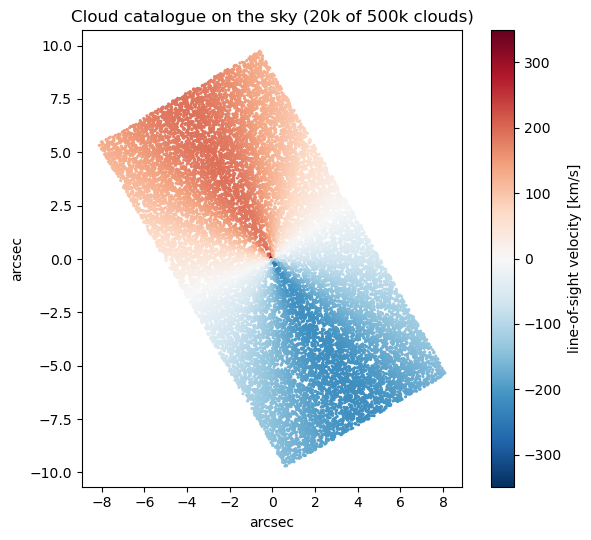

In [4]:
pos_img, vel_chan, flux = clouds.forward(theta, return_subsamples=True)
sub = torch.randperm(pos_img.shape[0])[:20000]     # subsample for plotting
x = pos_img[sub, 0, 0].cpu(); y = pos_img[sub, 0, 1].cpu()
v = (vel_chan[sub, 0] - vel_chan.mean()).cpu()

plt.figure(figsize=(6.5, 5.5))
vext = float(v.abs().max())
plt.scatter(x, y, c=v, s=1.5, cmap="RdBu_r",
            norm=colors.TwoSlopeNorm(vcenter=0, vmin=-vext, vmax=vext))
plt.colorbar(label="line-of-sight velocity [km/s]")
plt.xlabel("arcsec"); plt.ylabel("arcsec")
plt.title("Cloud catalogue on the sky (20k of 500k clouds)")
plt.gca().set_aspect("equal")
plt.tight_layout(); plt.show()

## 3. Monte-Carlo vs deterministic rendering

Render the *same* galaxy with `AnalyticInverse` (fresh model instances —
each renderer takes ownership of its velocity model's inclination
parameter) and compare.

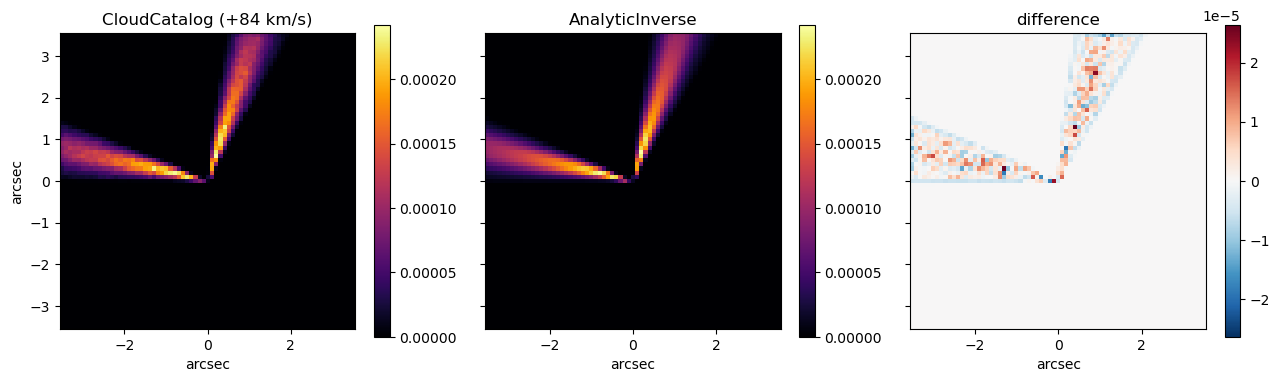

In [5]:
intensity2 = ExponentialDisk2D()
velocity2 = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                      device=device, dtype=dtype)
grid_sim = AnalyticInverse(intensity2, velocity2, freqs,
                           pixel_scale_arcsec=pixscale, N_pix_x=n_pix,
                           K_vel=8, oversamp_xy=4, oversamp_v=4,
                           device=device, dtype=dtype, line=line_hz)
pars_grid = dict(pars, distance_pc=distance_pc)
theta_grid = torch.tensor([pars_grid[p.name] for p in grid_sim.dynamic_params],
                          device=device, dtype=dtype)
cube_grid = grid_sim.forward(theta_grid)

# normalize both to unit total flux for a fair comparison
a = (cube_mc / cube_mc.sum()).detach().cpu().numpy()
b = (cube_grid / cube_grid.sum()).detach().cpu().numpy()

half_fov = pixscale * n_pix / 2
extent = (-half_fov, half_fov, -half_fov, half_fov)
ch = n_chan // 2 - 4
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
vmax = max(a[ch].max(), b[ch].max())
im0 = axes[0].imshow(a[ch], origin="lower", cmap="inferno", extent=extent, vmin=0, vmax=vmax)
axes[0].set_title(f"CloudCatalog ({vel_np[ch]:+.0f} km/s)")
im1 = axes[1].imshow(b[ch], origin="lower", cmap="inferno", extent=extent, vmin=0, vmax=vmax)
axes[1].set_title("AnalyticInverse")
d = a[ch] - b[ch]
dext = np.abs(d).max()
im2 = axes[2].imshow(d, origin="lower", cmap="RdBu_r", extent=extent,
                     norm=colors.TwoSlopeNorm(vcenter=0, vmin=-dext, vmax=dext))
axes[2].set_title("difference")
for im, ax in zip((im0, im1, im2), axes):
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xlabel("arcsec")
axes[0].set_ylabel("arcsec")
plt.tight_layout(); plt.show()

The two renderers agree on the structure; the difference map is dominated
by Monte-Carlo shot noise in the cloud version (plus slight differences in
sub-pixel sampling). Increase `N_clouds` (and `K_vel`) to push it down —
cost grows linearly.

## 4. Convergence with N_clouds

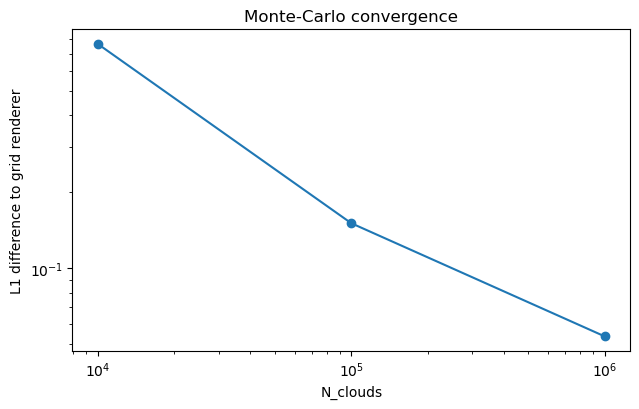

In [6]:
ref = b / b.sum()
plt.figure(figsize=(6.5, 4.2))
Ns = [1e4, 1e5, 1e6]
errs = []
for N in Ns:
    im_i = ExponentialDisk2D()
    vm_i = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                     device=device, dtype=dtype)
    cc = CloudCatalog(im_i, vm_i, fov_half_pc=700.0, N_clouds=int(N), K_vel=5,
                      brightness_init=None, distance_pc=distance_pc,
                      sampling_method="sobol_uniform", seed=1,
                      device=device, dtype=dtype)
    rr = CloudRasterizerOversample(cc, freqs, pixel_scale_arcsec=pixscale,
                                   N_pix_x=n_pix, oversamp_xy=4, oversamp_v=4,
                                   device=device, dtype=dtype, line=line_hz)
    th = torch.tensor([pars[p.name] for p in rr.dynamic_params],
                      device=device, dtype=dtype)
    cu = rr.forward(th)
    cu = (cu / cu.sum()).detach().cpu().numpy()
    errs.append(np.abs(cu - ref).sum())
plt.loglog(Ns, errs, "o-")
plt.xlabel("N_clouds"); plt.ylabel("L1 difference to grid renderer")
plt.title("Monte-Carlo convergence")
plt.tight_layout(); plt.show()

## Which renderer should I use?

- **`AnalyticInverse`** — default choice: deterministic, no shot noise,
  same cost per call, and exactly reproducible cubes.
- **`CloudCatalog` + `CloudRasterizerOversample`** — when your surface
  brightness cannot be written as `brightness(R)` on a grid (clumpy or
  stochastic structure), when porting a KinMS analysis, or when you want
  explicit control over how the disk is sampled.

Both plug into the visibility simulators identically — see the
[visibilities tutorial](04_visibilities.ipynb).